Calibrated Chi: 10.4343


C:\Users\65932\AppData\Local\Temp\ipykernel_27112\3710169981.py:145: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  k_ss_high = fsolve(lambda k: k_pol_high(k) - k, 10.0)[0]


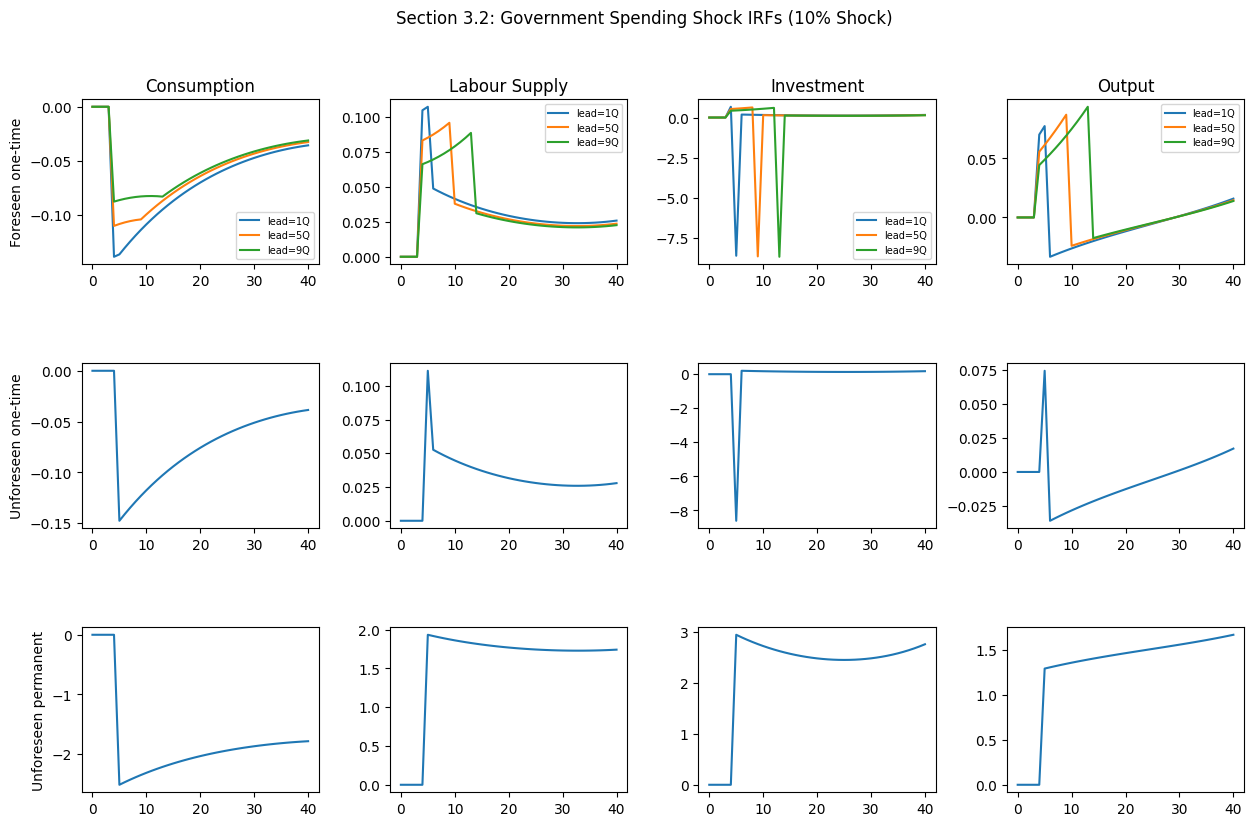

In [8]:
import numpy as np
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# =============================================================================
# 1. PARAMETERS & MARKOV SETUP
# =============================================================================
beta, sigma, phi, alpha, delta = 0.988, 1.0, 1.0, 0.33, 0.025
g_y_ratio = 0.20
target_L = 1/3

z_states = np.array([0.99, 1.01])
P = np.array([[0.875, 0.125], [0.125, 0.875]])

# --- Analytical Calibration of Chi ---
# Calibrate chi so that target_L = 1/3 is the steady state at z=1.0
rk_ss = (1/beta) - 1 + delta
kl_ratio = (rk_ss / (alpha * 1.0))**(1 / (alpha - 1))
k_ss_mid = kl_ratio * target_L
y_ss_mid = 1.0 * (k_ss_mid**alpha) * (target_L**(1-alpha))
w_ss_mid = (1 - alpha) * y_ss_mid / target_L
c_ss_mid = (1 - g_y_ratio) * y_ss_mid - delta * k_ss_mid
chi = (w_ss_mid * (c_ss_mid**-sigma)) / (target_L**phi)

print(f"Calibrated Chi: {chi:.4f}")

# =============================================================================
# 2. VFI FOR STEADY STATE POLICY
# =============================================================================
k_grid = np.linspace(1.0, 25.0, 200)
V = np.zeros((200, 2))
policy_idx = np.zeros((200, 2), dtype=int)

for _ in range(500):
    V_old = V.copy()
    EV = V_old @ P.T
    for i_z in range(2):
        Y = z_states[i_z] * (k_grid[:, None]**alpha) * (target_L**(1-alpha))
        C = (1 - g_y_ratio)*Y + (1 - delta)*k_grid[:, None] - k_grid[None, :]
        U = np.log(np.maximum(C, 1e-10)) - chi*(target_L**(1+phi))/(1+phi)
        U[C <= 1e-7] = -1e15
        V_mat = U + beta * EV[None, :, i_z]
        V[:, i_z] = np.max(V_mat, axis=1)
        policy_idx[:, i_z] = np.argmax(V_mat, axis=1)

k_policy = k_grid[policy_idx]
k_pol_high = interp1d(k_grid, k_policy[:, 1], kind='linear', fill_value="extrapolate")

# =============================================================================
# 3. CORE FUNCTIONS (SOLVER & HELPERS)
# =============================================================================
def solve_steady_state_fixed_G(z, chi_val, G_fixed):
    def equations(vars_vec):
        K, L, C = vars_vec
        Y = z * (K**alpha) * (L**(1-alpha))
        w = (1-alpha) * Y / L
        rk = alpha * Y / K
        return [beta * (rk + 1.0 - delta) - 1.0, chi_val * (L**phi) - w * (C**-sigma), Y - C - delta*K - G_fixed]
    sol = fsolve(equations, [k_ss_mid, target_L, c_ss_mid])
    Y_ss = z * (sol[0]**alpha) * (sol[1]**(1-alpha))
    return {"K": sol[0], "L": sol[1], "C": sol[2], "Y": Y_ss, "G": G_fixed, "I": delta*sol[0]}

def simulate_transition(k_start, z_val, g_path, chi_val, k_end=None):
    T = len(g_path)
    k_end = k_start if k_end is None else k_end
    init_guess = np.concatenate([np.full(T-1, k_start), np.full(T, target_L)])
    
    def equations(vars):
        K = np.zeros(T + 1); K[0], K[T] = k_start, k_end
        K[1:T], L = vars[:T-1], vars[T-1:]
        Y = z_val * (K[:-1]**alpha) * (L**(1-alpha))
        C = Y + (1-delta)*K[:-1] - K[1:] - g_path
        C_s = np.maximum(C, 1e-8)
        w = (1-alpha) * Y / L
        labor_res = chi_val * (L**phi) - (C_s**-sigma) * w
        rk_next = alpha * z_val * (K[1:T]**(alpha-1)) * (L[1:]**(1-alpha))
        euler_res = (C_s[:-1]**-sigma) - beta * (C_s[1:]**-sigma) * (rk_next + 1 - delta)
        return np.concatenate([euler_res, labor_res])

    sol = fsolve(equations, init_guess)
    K_f = np.zeros(T+1); K_f[0], K_f[T] = k_start, k_end; K_f[1:T] = sol[:T-1]
    L_f = sol[T-1:]
    Y_f = z_val * (K_f[:-1]**alpha) * (L_f**(1-alpha))
    I_f = K_f[1:] - (1-delta)*K_f[:-1]
    C_f = Y_f + (1-delta)*K_f[:-1] - K_f[1:] - g_path
    return {"K": K_f[:-1], "Y": Y_f, "C": C_f, "L": L_f, "I": I_f, "G": g_path}

def prepend_ss(res_dict, ss_ref, n_pre=5):
    out = {}
    for var, path in res_dict.items():
        out[var] = np.concatenate([np.full(n_pre, ss_ref[var]), path])
    return out

def pct_dev(path, ss_val):
    return 100.0 * (path - ss_val) / ss_val

def _with_visual_jump(tgrid, y, jump_t, eps=1e-3):
    t_plot = np.insert(tgrid, jump_t, tgrid[jump_t] - eps)
    y_plot = np.insert(y, jump_t, y[jump_t - 1])
    return t_plot, y_plot

# =============================================================================
# 4. PLOTTING SETUP
# =============================================================================
def plot_figure(foreseen_by_lead, res_unforeseen, res_permanent, ss, shock_size_pct):
    vars_plot = [("C", "Consumption"), ("L", "Labour Supply"), ("I", "Investment"), ("Y", "Output")]
    row_labels = ["Foreseen one-time", "Unforeseen one-time", "Unforeseen permanent"]
    tgrid = np.arange(41)

    fig, axes = plt.subplots(3, 4, figsize=(15, 9), gridspec_kw={"hspace": 0.6, "wspace": 0.3})
    
    for col, (var, var_label) in enumerate(vars_plot):
        # Row 1: Foreseen
        ax = axes[0, col]
        for lead, color in zip([1, 5, 9], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
            full = prepend_ss(foreseen_by_lead[lead], ss, n_pre=4)
            ax.plot(tgrid, pct_dev(full[var], ss[var]), label=f"lead={lead}Q", color=color)
        ax.set_title(var_label)
        if col==0: ax.set_ylabel(row_labels[0])
        ax.legend(fontsize=7)

        # Row 2: Unforeseen One-time
        ax = axes[1, col]
        full = prepend_ss(res_unforeseen, ss, n_pre=5)
        tx, yy = _with_visual_jump(tgrid, pct_dev(full[var], ss[var]), 5)
        ax.plot(tx, yy)
        if col==0: ax.set_ylabel(row_labels[1])

        # Row 3: Unforeseen Permanent
        ax = axes[2, col]
        full = prepend_ss(res_permanent, ss, n_pre=5)
        tx, yy = _with_visual_jump(tgrid, pct_dev(full[var], ss[var]), 5)
        ax.plot(tx, yy)
        if col==0: ax.set_ylabel(row_labels[2])
        
    plt.suptitle(f"Section 3.2: Government Spending Shock IRFs ({shock_size_pct}% Shock)")
    plt.show()

# =============================================================================
# 5. MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    z_ref = z_states[1] # Boom State (1.01)
    k_ss_high = fsolve(lambda k: k_pol_high(k) - k, 10.0)[0]
    ss_ref = solve_steady_state_fixed_G(z_ref, chi, g_y_ratio * (z_ref * k_ss_high**alpha * target_L**(1-alpha)))

    # Shock size: 10%
    size = 0.10
    
    # 1. Unforeseen
    G_unf = np.full(36, ss_ref["G"]); G_unf[0] *= (1+size)
    res_unf = simulate_transition(ss_ref["K"], z_ref, G_unf, chi)

    # 2. Foreseen
    foreseen_results = {}
    for lead in [1, 5, 9]:
        G_for = np.full(37, ss_ref["G"]); G_for[lead] *= (1+size)
        foreseen_results[lead] = simulate_transition(ss_ref["K"], z_ref, G_for, chi)

    # 3. Permanent
    G_perm = np.full(36, ss_ref["G"]*(1+size))
    ss_new = solve_steady_state_fixed_G(z_ref, chi, ss_ref["G"]*(1+size))
    res_perm = simulate_transition(ss_ref["K"], z_ref, G_perm, chi, k_end=ss_new["K"])

    plot_figure(foreseen_results, res_unf, res_perm, ss_ref, int(size*100))